# Aggregated Interface Interaction Analysis

Compare protein–protein interfaces across all deposited structures of one complex. Cluster the interfaces by interaction-pair similarity, then overlay mutations, modifications, and ligands to interpret what each cluster represents. Each cluster is treated as a candidate **interface interaction state** — a recurring pattern of residue–residue contacts that distinguishes a subset of structures from the rest.

## Configuration

Edit the `Config` instance below. The defaults are tuned for the working example.

Common adjustments: change `complex_id` to your target complex; broaden `mutation_type_filter` to include `"Conflict"` if you want to see strain variants; remove a chem_comp_id from `ligand_blocklist` to retain a catalytic metal or buffer component; set `exclude_assemblies_with_bound_macromolecules` to `False` to retain assemblies with a third macromolecular chain (a co-chaperone, antibody Fab, etc.) — by default these are dropped because the third chain can perturb the dimer interface.

In [19]:
import logging
from dataclasses import dataclass
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram

from pdbe_interfaces import api, representation, similarity, annotations, outputs


@dataclass
class Config:
    complex_id: str = "PDB-CPX-130306"  # SARS-CoV-2 Spike RBD + ACE2 (demo) "PDB-CPX-140195"
    mutation_type_filter: tuple = ("Engineered mutation",)
    ligand_blocklist: frozenset = frozenset({
        # ions / counter-ions
        "CL", "NA", "MG", "ZN", "CA", "K",
        # buffers / cryoprotectants / reducing agents
        "SO4", "GOL", "HOH", "EDO", "PEG", "MPD", "ACT",
        "SGM", "DTT", "BME", "TRS",
    })
    drop_carbohydrate_polymers: bool = False
    exclude_assemblies_with_bound_macromolecules: bool = True
    max_resolution: float | None = None  # set e.g. 2.0 to keep only assemblies at 2 Å or better
    conservation_threshold: float = 0.8
    cluster_distance_cut: float = 0.6
    log_level: str = "INFO"
    output_dir: str | None = "interface_frequencies"  # JSON exports land here; created if missing


cfg = Config()

logging.basicConfig(
    level=cfg.log_level,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
logging.getLogger("urllib3").setLevel(logging.WARNING)

cfg

Config(complex_id='PDB-CPX-130306', mutation_type_filter=('Engineered mutation',), ligand_blocklist=frozenset({'CL', 'NA', 'SGM', 'BME', 'SO4', 'EDO', 'HOH', 'MG', 'K', 'MPD', 'ACT', 'GOL', 'CA', 'PEG', 'ZN', 'TRS', 'DTT'}), drop_carbohydrate_polymers=False, exclude_assemblies_with_bound_macromolecules=True, max_resolution=None, conservation_threshold=0.8, cluster_distance_cut=0.6, log_level='INFO', output_dir='interface_frequencies')

## Phase 1 — Data retrieval

We validate the complex ID, confirm it is a dimer (v1 limitation, set by the `interface_interactions` API), apply the assembly filter (drop assemblies whose `bound_macromolecules` list is non-empty in `complex/details`), and fetch interfaces, mutations, modifications, and ligands. Annotations covering all retained PDB entries are batched. Per-entry calls are sequential. Expect 30–120 seconds for a complex like the working example.

In [20]:
details = api.fetch_complex_details(cfg.complex_id)
if details.get("total_chains") != 2:
    raise ValueError(
        f"Complex {cfg.complex_id} has {details.get('total_chains')} chains; "
        "v1 supports dimer complexes only — this is an upstream limitation of "
        "the interface_interactions API, not a design choice. Higher-order "
        "oligomers are a planned v2 extension."
    )

partner_map = outputs.build_partner_map(details)
assembly_metadata = outputs.extract_assembly_metadata(details)
print(f"Complex: {details.get('name')}")
print(f"Oligomeric state: {details.get('oligomeric_state')}")
print(f"Partners: {partner_map}")
print(f"Assembly metadata captured for {len(assembly_metadata)} (pdb_id, assembly_id) pairs")

14:36:39 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/complex/details/PDB-CPX-130306?id_type=pdb_complex_id


Complex: GTPase KRas, N-terminally processed and RAF proto-oncogene serine/threonine-protein kinase
Oligomeric state: Heterodimer
Partners: {('P01116', 1): 'KRAS', ('P04049', 2): 'RAF1'}
Assembly metadata captured for 12 (pdb_id, assembly_id) pairs


In [21]:
interface_response = api.fetch_interface_interactions(cfg.complex_id)
if cfg.exclude_assemblies_with_bound_macromolecules or cfg.max_resolution is not None:
    valid = representation.valid_assemblies(details, max_resolution=cfg.max_resolution)
    interface_response, dropped = representation.filter_interfaces_by_assembly(
        interface_response, valid,
    )
    if not interface_response:
        raise ValueError(
            f"No interfaces remain for {cfg.complex_id} after assembly filters "
            f"(bound_macromolecules={cfg.exclude_assemblies_with_bound_macromolecules}, "
            f"max_resolution={cfg.max_resolution}). "
            "Loosen the filters in Config to override."
        )
    print(f"Assembly filter dropped {len(dropped)} interfaces "
          f"(bound_macromolecules and/or resolution > {cfg.max_resolution})")
pdb_ids = sorted({it["entry_id"] for it in interface_response})
print(f"Interfaces retained: {len(interface_response)} across {len(pdb_ids)} PDB entries")
print(f"PDB entries: {pdb_ids}")

14:36:40 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/complex/interface_interactions/PDB-CPX-130306


Assembly filter dropped 0 interfaces (bound_macromolecules and/or resolution > None)
Interfaces retained: 12 across 9 PDB entries
PDB entries: ['6vjj', '6xgu', '6xgv', '6xha', '6xhb', '6xi7', '8epw', '8t74', '8t75']


In [22]:
mutations_response = api.fetch_mutations(pdb_ids)
modifications_response = api.fetch_modifications(pdb_ids)
n_mut = sum(len(v or []) for v in (mutations_response or {}).values())
n_mod = sum(len(v or []) for v in (modifications_response or {}).values())
print(f"Mutation records (all types): {n_mut}")
print(f"Modification records: {n_mod}")

14:36:40 [INFO] pdbe_interfaces.api: Batched POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/mutated_AA_or_NA: chunk 1-9 of 9
14:36:40 [INFO] pdbe_interfaces.api: POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/mutated_AA_or_NA
14:36:40 [INFO] pdbe_interfaces.api: Batched POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/modified_AA_or_NA: chunk 1-9 of 9
14:36:40 [INFO] pdbe_interfaces.api: POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/modified_AA_or_NA


Mutation records (all types): 60
Modification records: 8


In [23]:
ligand_contacts_by_pdb = {}
for pdb_id in pdb_ids:
    bm_records = api.fetch_bound_molecules(pdb_id)
    surviving = annotations.filter_bound_molecules(
        bm_records,
        blocklist=cfg.ligand_blocklist,
        drop_carbohydrate_polymers=cfg.drop_carbohydrate_polymers,
    )
    contacts = annotations.collect_ligand_contacts(pdb_id, surviving)
    ligand_contacts_by_pdb[pdb_id] = contacts
n_lig_contacts = sum(len(v) for v in ligand_contacts_by_pdb.values())
print(f"Ligand contact tuples (all interfaces, post-filter): {n_lig_contacts}")

14:36:40 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/6vjj
14:36:40 [INFO] pdbe_interfaces.annotations: Filtered out 7 ligand instances: ['CL', 'EDO', 'MG', 'MPD']
14:36:40 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/6vjj/A/202?preserve_case=false
14:36:40 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/6xgu
14:36:40 [INFO] pdbe_interfaces.annotations: Filtered out 6 ligand instances: ['GOL', 'MG', 'ZN']
14:36:40 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/6xgu/A/201?preserve_case=false
14:36:41 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/6xgv
14:36:41 [INFO] pdbe_interfaces.annotations: Filtered out 7 ligand instances: ['CL', 'GOL', 'MG', 'ZN']
14:36:41 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/6xgv/A/201?prese

Ligand contact tuples (all interfaces, post-filter): 793


## Phase 2 — Build representations

Each interface is represented as a set of `(residue_1, residue_2, bond_type)` tuples. We build two versions: one keyed by author chain and residue number (used for joining annotations within a structure), one keyed by UniProt accession and sequence position with a role label (used for comparison across structures).

Atom-level contacts in the response are aggregated to one element per `(residue_pair, bond_type)`. Atom-level detail is not retained.

Interface residues lacking a UniProt mapping are dropped — these are usually termini or expression-tag residues, and they are not comparable across structures anyway.

In [24]:
records = representation.build_interface_records(interface_response)
records = representation.check_partner_consistency(records)

summary = pd.DataFrame([
    {
        "pdb_id": r.pdb_id,
        "assembly_id": r.assembly_id,
        "interface_id": r.interface_id,
        "n_author_pairs": len(r.author_pairs),
        "n_uniprot_pairs": len(r.uniprot_pairs),
        "n_dropped_no_uniprot": r.n_residues_dropped_no_uniprot,
        "n_microheterogeneity": r.n_microheterogeneity_collisions,
    }
    for r in records
])
summary

,pdb_id,assembly_id,interface_id,n_author_pairs,n_uniprot_pairs,n_dropped_no_uniprot,n_microheterogeneity
0,6vjj,1,1,15,15,0,0
1,6xgu,1,1,24,24,0,0
2,6xgv,1,1,22,22,0,0
3,6xha,1,1,17,17,0,0
4,6xhb,1,1,22,22,0,0
5,6xi7,1,1,24,24,0,0
6,8epw,1,1,11,11,0,0
7,8t74,1,1,10,10,0,0
8,8t75,1,1,19,19,0,0
9,8t75,2,1,22,22,0,0


## Phase 3 — Similarity and clustering

Jaccard similarity between two interfaces is the fraction of interaction-pair tuples they share. We cluster by hierarchical clustering with average linkage on `1 − Jaccard` distance.

The dendrogram is the source of truth — adjust `cluster_distance_cut` after looking at it.

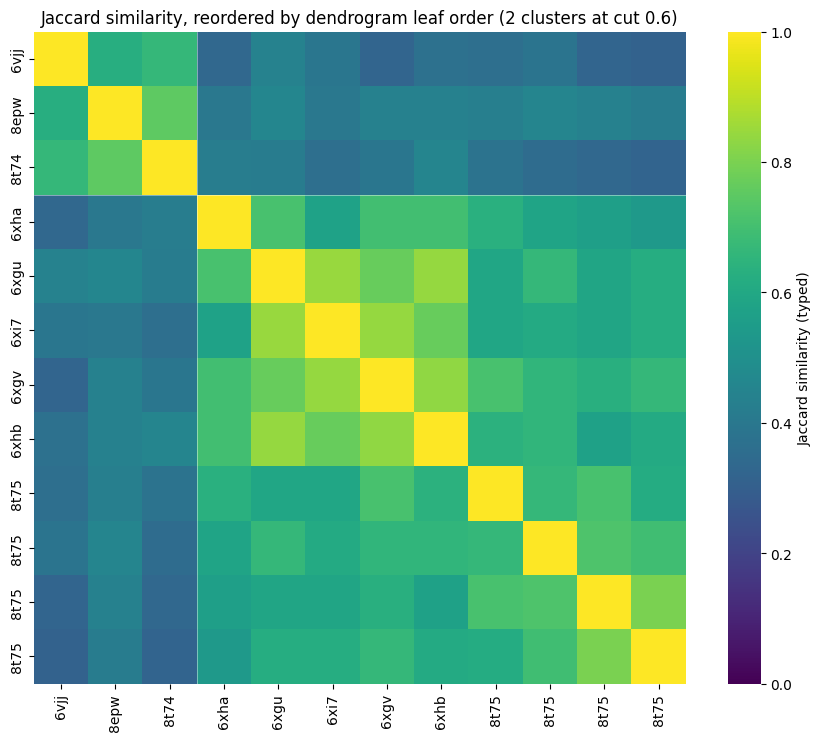

In [25]:
from scipy.cluster.hierarchy import leaves_list

uniprot_sets = [r.uniprot_pairs for r in records]
uniprot_sets_untyped = [similarity.untyped(s) for s in uniprot_sets]

sim_typed = similarity.jaccard_similarity_matrix(uniprot_sets)
sim_untyped = similarity.jaccard_similarity_matrix(uniprot_sets_untyped)

# Compute clustering up-front so the heatmap can be reordered by leaf order —
# clusters appear as bright squares on the diagonal instead of being scattered
# in API-fetch order.
cluster_result = similarity.cluster_interfaces(sim_typed, distance_cut=cfg.cluster_distance_cut)

labels = [outputs.label_for_record(r) for r in records]

n = len(records)
if n >= 2:
    leaf_order = leaves_list(cluster_result.linkage)
    sim_typed_reordered = sim_typed[leaf_order, :][:, leaf_order]
    labels_reordered = [labels[i] for i in leaf_order]

    # Cluster boundary positions in the reordered matrix — draw lines between
    # neighbouring leaves whose cluster id changes, so block structure is visible.
    flat = cluster_result.flat_assignment
    boundaries = [
        i for i in range(1, len(leaf_order))
        if flat[leaf_order[i]] != flat[leaf_order[i - 1]]
    ]

    fig, ax = plt.subplots(figsize=(max(6, 0.5 * n + 3), max(5, 0.45 * n + 2)))
    sns.heatmap(
        sim_typed_reordered,
        ax=ax,
        cmap="viridis",
        square=True,
        cbar_kws={"label": "Jaccard similarity (typed)"},
        xticklabels=labels_reordered,
        yticklabels=labels_reordered,
        vmin=0.0,
        vmax=1.0,
    )
    for b in boundaries:
        ax.axhline(b, color="white", linewidth=0.5, alpha=0.6)
        ax.axvline(b, color="white", linewidth=0.5, alpha=0.6)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_title(f"Jaccard similarity, reordered by dendrogram leaf order "
                 f"({len(set(flat))} clusters at cut {cfg.cluster_distance_cut})")
    plt.tight_layout()
    plt.show()
else:
    print("Only one interface; similarity matrix is trivial.")

Max |typed - untyped| Jaccard difference: 0.000
Substantial divergence (>~0.2) suggests bond-type assignment is doing more work than the residue-pair topology.

Cluster cut sweep — pick a cut from a stable plateau (same n_clusters across a range)
or read off where biology-vs-methodology balance feels right:


,cut,n_clusters,largest_5_sizes,n_singletons
0,0.30,6,"[4, 3, 2, 1, 1]",3
1,0.40,2,"[9, 3]",0
2,0.50,2,"[9, 3]",0
3,0.55,2,"[9, 3]",0
4,0.60,2,"[9, 3]",0
5,0.65,1,[12],0
6,0.70,1,[12],0


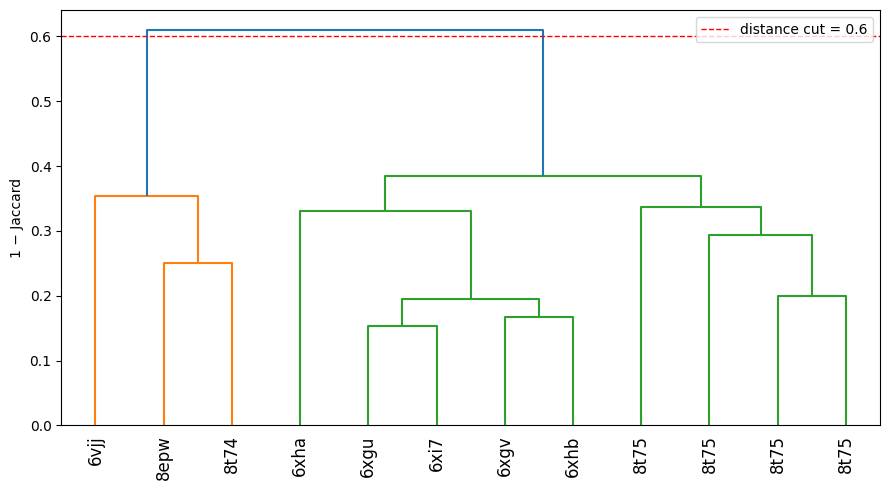

Number of clusters at distance cut 0.6: 2


In [26]:
if n >= 2:
    diff = float(np.abs(sim_typed - sim_untyped).max())
    print(f"Max |typed - untyped| Jaccard difference: {diff:.3f}")
    print("Substantial divergence (>~0.2) suggests bond-type assignment is doing more work than the residue-pair topology.")

if n >= 2:
    print()
    print("Cluster cut sweep — pick a cut from a stable plateau (same n_clusters across a range)")
    print("or read off where biology-vs-methodology balance feels right:")
    sweep = similarity.sweep_cluster_cuts(cluster_result.linkage)
    display(sweep)

    fig, ax = plt.subplots(figsize=(max(8, 0.5 * n + 3), 5))
    dendrogram(
        cluster_result.linkage,
        labels=labels,
        leaf_rotation=90,
        ax=ax,
    )
    ax.axhline(cfg.cluster_distance_cut, color="red", linestyle="--", linewidth=1,
               label=f"distance cut = {cfg.cluster_distance_cut}")
    ax.set_ylabel("1 − Jaccard")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    print(f"Number of clusters at distance cut {cfg.cluster_distance_cut}: {len(set(cluster_result.flat_assignment))}")
else:
    print("Need at least two interfaces to cluster.")

## Phase 4 — Annotation overlap

Mutations, modifications, and ligand-contact residues are joined onto interface residues. Annotations falling outside the interface are dropped: this workflow is about what happens *at* the interface. A residue carrying a peripheral mutation will not show that mutation in its overlap row; the structure table reflects interface counts only.

In [27]:
overlap = annotations.overlap_annotations(
    records,
    mutations_response=mutations_response,
    modifications_response=modifications_response,
    ligand_contacts_by_pdb=ligand_contacts_by_pdb,
    mutation_type_filter=cfg.mutation_type_filter,
)
print(f"Mutation overlaps at interfaces: {len(overlap.mutations)}")
print(f"Modification overlaps at interfaces: {len(overlap.modifications)}")
print(f"Ligand contact overlaps at interfaces: {len(overlap.ligands)}")

Mutation overlaps at interfaces: 0
Modification overlaps at interfaces: 0
Ligand contact overlaps at interfaces: 12


In [28]:
if overlap.mutations.empty:
    print("No engineered mutations found at any interface for this complex.")
else:
    display(overlap.mutations.head(20))

No engineered mutations found at any interface for this complex.


In [29]:
if overlap.ligands.empty:
    print("No ligand contacts at any interface for this complex (after applying ligand_blocklist and the carbohydrate-polymer filter).")
else:
    display(overlap.ligands.head(20))

,pdb_id,assembly_id,interface_id,auth_asym_id,auth_seq_id,ins_code,unp_acc,unp_seq_id,role,ligand_chem_comp_id,ligand_chain_id,ligand_author_residue_number,contact_type
0,6vjj,1,1,A,31,None,P01116,31,1,GNP,A,202,weak_hbond
1,6vjj,1,1,A,31,None,P01116,31,1,GNP,A,202,weak_polar
2,6vjj,1,1,A,34,None,P01116,34,1,GNP,A,202,weak_polar
3,6xgu,1,1,A,31,None,P01116,31,1,GNP,A,201,weak_polar
4,6xgu,1,1,A,31,None,P01116,31,1,GNP,A,201,weak_hbond
5,6xgu,1,1,A,31,None,P01116,31,1,GNP,A,201,vdw
6,6xhb,1,1,A,31,None,P01116,31,1,GNP,A,201,weak_hbond
7,6xi7,1,1,A,31,None,P01116,31,1,GNP,A,201,weak_hbond
8,6xi7,1,1,A,31,None,P01116,31,1,GNP,A,201,weak_polar
9,6xi7,1,1,A,31,None,P01116,31,1,GNP,A,201,vdw


## Phase 5 — Summarisation and interpretation

The structure table consolidates one row per interface. Conserved residues and conserved interaction pairs are those present in at least `conservation_threshold` of interfaces (default 0.8). The cluster interpretation report reads each cluster as a candidate **interface interaction state** and surfaces:

- per-interface distributions of residue-pair count, typed-interaction count, and PISA interface area (min / median / mean / max), plus median contact density (interactions / Å²);
- **core contacts** — typed contacts present in ≥ `conservation_threshold` of cluster members;
- enriched contacts and annotations (mutations / modifications / ligands) vs the rest of the dataset;
- **QC warnings** for singleton clusters, sparse fingerprints, tiny interfaces, and clusters whose UniProt residue range poorly overlaps the dominant cluster (e.g. polyprotein / processed-product / domain mixups).

In [30]:
fetch_date = date.today().isoformat()
structure_table = outputs.build_structure_table(
    records, cluster_result, overlap, partner_map, fetch_date,
    assembly_metadata=assembly_metadata,
)
structure_table

,pdb_id,assembly_id,interface_id,partner_1,partner_2,experimental_method,resolution,interface_area,solvation_energy,stabilisation_energy,...,n_salt_bridges,n_covalent_bonds,n_disulfide_bonds,n_engineered_mutations_at_interface,n_modifications_at_interface,n_distinct_ligands_at_interface,n_ligand_contact_residues_at_interface,cluster_id,n_residues_dropped_no_uniprot,fetch_date
0,6vjj,1,1,KRAS,RAF1,X-ray diffraction,1.40,651.41,0.94,-8.55,...,10,0,0,0,0,1,2,1,0,2026-05-18
1,6xgu,1,1,KRAS,RAF1,X-ray diffraction,2.70,1150.63,-0.86,-13.98,...,9,0,0,0,0,1,1,2,0,2026-05-18
2,6xgv,1,1,KRAS,RAF1,X-ray diffraction,2.11,1159.05,-0.26,-13.83,...,9,0,0,0,0,0,0,2,0,2026-05-18
3,6xha,1,1,KRAS,RAF1,X-ray diffraction,2.87,1096.57,-2.44,-11.85,...,5,0,0,0,0,0,0,2,0,2026-05-18
4,6xhb,1,1,KRAS,RAF1,X-ray diffraction,2.50,1175.05,-0.86,-13.60,...,8,0,0,0,0,1,1,2,0,2026-05-18
5,6xi7,1,1,KRAS,RAF1,X-ray diffraction,1.95,1214.77,-0.77,-14.18,...,5,0,0,0,0,1,1,2,0,2026-05-18
6,8epw,1,1,KRAS,RAF1,X-ray diffraction,2.00,695.24,1.23,-5.89,...,6,0,0,0,0,0,0,1,0,2026-05-18
7,8t74,1,1,KRAS,RAF1,X-ray diffraction,1.65,632.35,2.19,-3.15,...,6,0,0,0,0,1,1,1,0,2026-05-18
8,8t75,1,1,KRAS,RAF1,X-ray diffraction,2.65,1159.68,-2.12,-13.09,...,8,0,0,0,0,0,0,2,0,2026-05-18
9,8t75,2,1,KRAS,RAF1,X-ray diffraction,2.65,1137.89,0.82,-13.05,...,11,0,0,0,0,0,0,2,0,2026-05-18


In [31]:
conserved_res = outputs.conserved_residues(records, threshold=cfg.conservation_threshold)
conserved_pairs = outputs.conserved_interaction_pairs(records, threshold=cfg.conservation_threshold)
print(f"Conserved residues at threshold {cfg.conservation_threshold}: {len(conserved_res)}")
print(f"Conserved interaction pairs at threshold {cfg.conservation_threshold}: {len(conserved_pairs)}")

Conserved residues at threshold 0.8: 10
Conserved interaction pairs at threshold 0.8: 8


In [32]:
report = outputs.cluster_interpretation_report(
    records, cluster_result, overlap,
    assembly_metadata=assembly_metadata,
    partner_map=partner_map,
    conservation_threshold=cfg.conservation_threshold,
)
for _, row in report.iterrows():
    # `notes` is a multi-line string containing the headline plus indented
    # statistics / core-contacts / QC lines.
    print(row["notes"])
    if row["enriched_contacts"]:
        print(f"  Enriched contacts (vs rest of dataset): {row['enriched_contacts']}")
    print()
report

Interface interaction state 1 (3 interfaces): ligands enriched at the interface — GNP (2, 2.0x) (2/3 carry an at-interface ligand contact). [methods: X-ray diffraction (3); resolution: 1.40–2.00 Å (median 1.65, n=3)]
  Residue pair count: 10–15, median 11
  Interaction count: 10–15, median 11
  Interface area: 632–695 Å², median 651
  Contact density: median 0.0169 interactions/Å²
  Core contacts (>= conservation_threshold of members): KRAS:D33-RAF1:K84 salt_bridge (3/3, 100.0%); KRAS:E37-RAF1:R59 salt_bridge (3/3, 100.0%); KRAS:E37-RAF1:R67 salt_bridge (3/3, 100.0%); KRAS:E37-RAF1:V69 hydrogen_bond (3/3, 100.0%); KRAS:D38-RAF1:T68 hydrogen_bond (3/3, 100.0%); KRAS:D38-RAF1:R89 salt_bridge (3/3, 100.0%); KRAS:S39-RAF1:R67 hydrogen_bond (3/3, 100.0%); KRAS:S39-RAF1:R89 hydrogen_bond (3/3, 100.0%); KRAS:R41-RAF1:Q66 hydrogen_bond (3/3, 100.0%)
  Enriched contacts (vs rest of dataset): KRAS:M67-RAF1:R59 hydrogen_bond (1, exclusive); KRAS:P34-RAF1:N71 hydrogen_bond (1, exclusive); KRAS:D33

,cluster_id,cluster_size,member_pdb_ids,experimental_methods,resolution_range,interface_area_range,residue_pair_count_min,residue_pair_count_median,residue_pair_count_mean,residue_pair_count_max,...,enriched_mutations,enriched_modifications,enriched_ligands,enriched_contacts,interfaces_with_any_mutation,interfaces_with_any_modification,interfaces_with_any_ligand,annotation_correlate_present,qc_warnings,notes
0,1,3,"6vjj,8epw,8t74",X-ray diffraction (3),"1.40–2.00 Å (median 1.65, n=3)","632–695 Å² (median 651, n=3)",10.0,11.0,12.000000,15.0,...,,,"GNP (2, 2.0x)","KRAS:M67-RAF1:R59 hydrogen_bond (1, exclusive)...",0,0,2,True,,Interface interaction state 1 (3 interfaces): ...
1,2,9,"6xgu,6xgv,6xha,6xhb,6xi7,8t75",X-ray diffraction (9),"1.95–2.87 Å (median 2.65, n=9)","1097–1215 Å² (median 1151, n=9)",17.0,22.0,21.555556,24.0,...,,,,"KRAS:Q43-RAF1:H139 hydrogen_bond (9, exclusive...",0,0,3,False,,Interface interaction state 2 (9 interfaces): ...


## Phase 5a — Key residue pairs (interactive)

The heatmap shows within-cluster residue-pair frequencies. Use the **core contact table** and **pair-count statistics** in the cluster interpretation report above to interpret whether a cluster represents a conserved interface state, an expanded interface, a sparse interface, or a possible outlier.

Side-by-side view of "what's actually doing the binding" with **dynamic filtering by interface interaction state**:

- **Left:** top residue-pair table — UniProt-keyed contact pairs (collapsed across bond_type), ranked by how many interfaces contain each pair.
- **Right:** residue-pair frequency heatmap — partner-1 residues × partner-2 residues, cell value = fraction of interfaces containing that pair. Both axes show the top-N residues by frequency, ordered by ascending UniProt residue number for readability.

**Use the controls at the top:**
- `Filter:` dropdown — `"All clusters"` for the dataset-wide view, or pick a specific interface interaction state to see what its members share.
- `Top N` slider — caps the table rows and the heatmap dimension on each side.

When you filter to a single state, the table and heatmap show the residue-pair signature *of that state only* — the natural complement to `cluster_interpretation_report` (which shows what's enriched vs the rest).

In [33]:
from collections import Counter
import ipywidgets as widgets
from IPython.display import clear_output

cluster_assign = cluster_result.flat_assignment
cluster_sizes_dict = Counter(cluster_assign.tolist())

# Build dropdown options: "All clusters" + each cluster sorted by size descending.
options = [("All clusters", "all")]
for cid, sz in sorted(cluster_sizes_dict.items(), key=lambda x: (-x[1], x[0])):
    options.append((f"Cluster {cid} (n={sz})", str(cid)))

cluster_dropdown = widgets.Dropdown(
    options=options,
    value="all",
    description="Filter:",
    style={"description_width": "initial"},
)
top_n_slider = widgets.IntSlider(
    value=15, min=5, max=40, step=5,
    description="Top N rows / heatmap size",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"),
)

# Two output widgets, displayed side by side.
table_out = widgets.Output(layout=widgets.Layout(width="42%", overflow="auto"))
plot_out = widgets.Output(layout=widgets.Layout(width="58%", overflow="auto"))


def _render(change=None):
    sel = cluster_dropdown.value
    top_n = top_n_slider.value
    if sel == "all":
        subset = records
        scope = f"all {len(subset)} interfaces"
    else:
        cid = int(sel)
        subset = [r for i, r in enumerate(records) if cluster_assign[i] == cid]
        scope = f"cluster {cid} only ({len(subset)} interfaces)"

    with table_out:
        clear_output(wait=True)
        if not subset:
            print("No interfaces in this selection.")
        else:
            freq = outputs.interface_frequency_summary(subset, partner_map=partner_map)
            print(f"Top {top_n} residue pairs ({scope})")
            display(freq["pairs"][["contact", "n_interfaces", "fraction"]].head(top_n))

    with plot_out:
        clear_output(wait=True)
        if not subset:
            return
        freq = outputs.interface_frequency_summary(subset, partner_map=partner_map)
        matrix = freq["pair_matrix"]
        p1_lab = freq["partner_1_labels"]
        p2_lab = freq["partner_2_labels"]
        n_int = freq["n_interfaces"]
        p1_show = min(len(p1_lab), top_n)
        p2_show = min(len(p2_lab), top_n)
        if p1_show == 0 or p2_show == 0:
            print("No residue pairs to plot.")
            return
        # Pick the top-N residues per axis (rows are already frequency-desc),
        # then reorder that selection by ascending UniProt residue position so
        # the axes read left-to-right / top-to-bottom in residue-number order.
        p1_table = freq["partner_1_residues"]
        p2_table = freq["partner_2_residues"]
        p1_idx = sorted(range(p1_show), key=lambda i: int(p1_table.iloc[i]["position"]))
        p2_idx = sorted(range(p2_show), key=lambda i: int(p2_table.iloc[i]["position"]))
        matrix_show = matrix[p1_idx, :][:, p2_idx] / max(n_int, 1)
        xticks = [p2_lab[i] for i in p2_idx]
        yticks = [p1_lab[i] for i in p1_idx]
        fig, ax = plt.subplots(figsize=(max(5, 0.32 * p2_show), max(4, 0.3 * p1_show)))
        sns.heatmap(
            matrix_show, ax=ax, cmap="viridis",
            xticklabels=xticks, yticklabels=yticks,
            vmin=0.0, vmax=1.0,
            cbar_kws={"label": f"fraction of {n_int}"},
            linewidths=0.3, linecolor="white",
        )
        ax.set_xlabel("Partner 2 residue")
        ax.set_ylabel("Partner 1 residue")
        ax.set_title(f"Top {p1_show}×{p2_show} pairs, {scope}")
        plt.tight_layout()
        plt.show()


cluster_dropdown.observe(_render, names="value")
top_n_slider.observe(_render, names="value")
display(widgets.VBox([
    widgets.HBox([cluster_dropdown, top_n_slider]),
    widgets.HBox([table_out, plot_out]),
]))
_render()

## Phase 5b — Interface rewiring between interaction states

This table highlights contacts that are conserved, lost, gained, or rewired between candidate interface interaction states. For each typed contact, it reports the count and fraction of interfaces in each cluster, the difference in fractions, and a label:

- **shared core** — present in ≥ 80% of members in *both* states (the conserved core);
- **A-enriched** / **B-enriched** — fraction differs by ≥ 0.5 (a contact that is gained or lost between states);
- **rare** — neither state shows strong enrichment.

By default the two largest non-singleton states are compared. Pass `cluster_a` / `cluster_b` to `outputs.compare_cluster_contacts(...)` to compare any two states from the report above.

In [34]:
# Default to the two largest non-singleton interface interaction states.
# Override by passing cluster_a / cluster_b explicitly to compare any pair.
try:
    rewiring = outputs.compare_cluster_contacts(
        records, cluster_result,
        partner_map=partner_map,
        top_n=20,
    )
    cid_a = rewiring.attrs.get("cluster_a")
    cid_b = rewiring.attrs.get("cluster_b")
    sz_a = rewiring.attrs.get("size_a")
    sz_b = rewiring.attrs.get("size_b")
    print(
        f"Rewiring: state {cid_a} (n={sz_a}) vs state {cid_b} (n={sz_b}). "
        f"Sorted by |fraction_difference| desc; top 20."
    )
    display(rewiring)
except ValueError as e:
    print(f"Cannot build rewiring table: {e}")

Rewiring: state 2 (n=9) vs state 1 (n=3). Sorted by |fraction_difference| desc; top 20.


,contact,cluster_A_count,cluster_B_count,cluster_A_fraction,cluster_B_fraction,fraction_difference,enrichment_direction
0,KRAS:D47-RAF1:E174 hydrogen_bond,9,0,1.000,0.000,1.000,A-enriched
1,KRAS:Q43-RAF1:H139 hydrogen_bond,9,0,1.000,0.000,1.000,A-enriched
2,KRAS:R149-RAF1:T178 hydrogen_bond,9,0,1.000,0.000,1.000,A-enriched
3,KRAS:V45-RAF1:S177 hydrogen_bond,9,0,1.000,0.000,1.000,A-enriched
4,KRAS:E153-RAF1:T178 hydrogen_bond,8,0,0.889,0.000,0.889,A-enriched
5,KRAS:G48-RAF1:E174 hydrogen_bond,8,0,0.889,0.000,0.889,A-enriched
6,KRAS:K42-RAF1:V180 hydrogen_bond,8,0,0.889,0.000,0.889,A-enriched
7,KRAS:Y157-RAF1:S177 hydrogen_bond,7,0,0.778,0.000,0.778,A-enriched
8,KRAS:G48-RAF1:R143 hydrogen_bond,6,0,0.667,0.000,0.667,A-enriched
9,KRAS:D33-RAF1:K84 salt_bridge,4,3,0.444,1.000,-0.556,B-enriched


## Phase 6 — Visualise cluster representatives in Mol*

Renders one representative per cluster (stacked vertically), using MolViewSpec → Mol*. Both partner chains are coloured distinctly, interface residues shown as ball-and-stick, and at-interface mutations overlaid in red.

**How the representative is chosen:** the member of each cluster with the **best (lowest) resolution** from `complex/details`. Ties broken by `(pdb_id, assembly_id, interface_id)` for determinism. If `assembly_metadata` isn't provided, falls back to the first member by the same deterministic sort. This means two re-runs of the notebook always pick the same representative for the same cluster.

The cluster header line shows the chosen PDB ID, assembly, interface, and resolution so the basis of the choice is visible.

Defaults render up to 6 clusters with ≥5 members. Each viewer adds a few hundred kB to the notebook, so smaller clusters and singletons are skipped. Edit the call below to widen or narrow the selection.

In [35]:
from pdbe_interfaces import visualize

visualize.visualize_clusters_grid(
    records, cluster_result, overlap=overlap,
    assembly_metadata=assembly_metadata,  # picks best-resolution representative per cluster
    min_cluster_size=5,   # show clusters with at least 5 members
    max_clusters=6,       # show at most 6 clusters
)

**Showing 1 cluster representatives** (min_cluster_size=5, max_clusters=6). Skipped: 1 smaller clusters.

### Cluster 2 (n=9) — representative `6xi7` (assembly 1, interface 1, 1.95 Å)

<IPython.core.display.Javascript object>

## Phase 7 — Export interface conservation JSON

Lightweight export of UniProt residue-level interface conservation and residue–residue contact frequencies for downstream visualisation (Mol* colouring by conservation, frontend contact matrices/heatmaps, AFDB-style overlays).

This is an export-only step — clustering, the heatmap, and the interface-state report are unaffected. The file is written to `cfg.output_dir` (or the current directory if `output_dir` is `None`) as `{complex_id}_interface_frequencies.json`. Residue conservation is bucketed into `strong` (≥0.80), `medium` (0.50–0.79), `weak` (0.20–0.49), and `rare` (<0.20).

In [36]:
export_data = outputs.export_interface_frequency_json(
    records,
    partner_map=partner_map,
    complex_id=cfg.complex_id,
    complex_name=details.get("name"),
    oligomeric_state=details.get("oligomeric_state"),
    config=cfg,
    typed_contacts=True,
    complex_details=details,
)

print(f"Exported {len(export_data['residue_frequencies'])} residue frequencies")
print(f"Exported {len(export_data['contact_frequencies'])} contact frequencies")
print(f"Partners: {[p['label'] for p in export_data['partners']]}")

# Preview tables — sorted by frequency desc for readability. The exported JSON
# itself uses deterministic role/position ordering (see export function).
top_res = (
    pd.DataFrame(export_data["residue_frequencies"])
    .sort_values("frequency", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("\nTop 10 residues by interface frequency:")
print(top_res.to_string(index=False))

contact_rows = []
for c in export_data["contact_frequencies"]:
    contact_rows.append({
        "partner_1": c["partner_1"]["unp_residue_label"],
        "partner_2": c["partner_2"]["unp_residue_label"],
        "bond_type": c.get("bond_type", ""),
        "n_interfaces": c["n_interfaces"],
        "frequency": c["frequency"],
    })
top_contacts = (
    pd.DataFrame(contact_rows)
    .sort_values("frequency", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("\nTop 10 residue–residue contacts by interface frequency:")
print(top_contacts.to_string(index=False))

Exported 41 residue frequencies
Exported 36 contact frequencies
Partners: ['KRAS', 'RAF1']

Top 10 residues by interface frequency:
unp_accession  role  unp_residue_number unp_residue_label  n_interfaces  frequency conservation_level
       P04049     2                  89               R89            12     1.0000             strong
       P04049     2                  69               V69            12     1.0000             strong
       P04049     2                  68               T68            12     1.0000             strong
       P04049     2                  67               R67            12     1.0000             strong
       P04049     2                  66               Q66            12     1.0000             strong
       P01116     1                  37               E37            12     1.0000             strong
       P01116     1                  38               D38            12     1.0000             strong
       P01116     1                  39             